In [47]:
# ============================================================
# BLA -> PL ChR Respiration
# Cohort 2 - RI1 Home Cage Day 1
# ============================================================

import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BORIS_DIR = r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\BORIS_csv"

H5_DIR = r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs"

# ------------------------------------------------------------
# FIND FILES
# ------------------------------------------------------------

boris_files = sorted(glob.glob(os.path.join(BORIS_DIR, "*.csv")))
h5_files = sorted(glob.glob(os.path.join(H5_DIR, "*.h5")))

# Exclude social-agent BORIS scoring files
boris_files = [
    f for f in boris_files
    if not os.path.basename(f).lower().endswith("_sa.csv")
]

print(f"BORIS files: {len(boris_files)}")
print(f"H5 files:    {len(h5_files)}")

print("\nBORIS FILES")
for f in boris_files:
    print("  ", os.path.basename(f))

print("\nH5 FILES")
for f in h5_files:
    print("  ", os.path.basename(f))
    

BORIS files: 44
H5 files:    44

BORIS FILES
   10_1RI1_c_on_20260711_105641recfinal.csv
   10_1_RI1_e_off_20260712_102415recfinal.csv
   10_2_RI1_b_on_20260712_125143recfinal.csv
   10_2_RI1_l_off_20260711_132243.rec.csv
   10_3_RI1_b_on_20260711_142620.rec.csv
   10_3_RI1_e_off_20260712_135803.rec.csv
   10_4_RI1_k_off_20260711_122241.rec.csv
   10_4_RI1_p_on_20260712_111439.rec 2.csv
   11_2_RI1_d_on_20260712_131331.csv
   11_2_RI1_p_off_20260711_134956.csv
   11_3_RI1_a_on_20260711_094020.csv
   11_3_RI1_j_off_20260712_093408.csv
   11_4_RI1_l_on_20260712_152353.csv
   11_4_RI1_p_off_20260711_153254.csv
   12_2_RI1_a_off_20260712_113812.rec.csv
   12_2_RI1_o_on_20260711_125255.rec.csv
   12_3_RI1_f_off_20260711_152022.rec.csv
   12_3_RI1_o_on_20260712_150307.rec.csv
   12_4_RI1_h_off_20260712_134330.rec.csv
   12_4_RI1_j_on_20260711_141535.rec.csv
   13_1_RI1_a_off_20260711_140435.csv
   13_1_RI1_f_on_20260712_133116.csv
   13_2_RI1_b_on_20260711_112656.csv
   13_2_RI1_o_off_202607

In [90]:
import os

OUT_FILE = r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\BORIS_csv\cohort2_RI1_social_bouts.csv"

long_social_bouts.to_csv(
    OUT_FILE,
    index=False
)

print("Saved:", os.path.exists(OUT_FILE))
print("Rows:", len(long_social_bouts))

Saved: True
Rows: 2112


In [48]:
# Cohort 2 experimental design
# All animals are male
# Even cages = GFP control
# Odd cages  = ChR experimental

def assign_group(cage):
    return "GFP" if cage % 2 == 0 else "ChR"

def assign_sex(cage):
    return "Male"

In [49]:
# ============================================================
# LOAD AND ORGANIZE COHORT 2 BORIS DATA
# Robust filename parsing
# ============================================================

import re

def load_boris_file(csv_path):
    df = pd.read_csv(csv_path)

    # Standardize timing column names
    df = df.rename(columns={
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration"
    })

    # Clean behavior labels
    if "Behavior" in df.columns:
        df["Behavior"] = (
            df["Behavior"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "Subject" in df.columns:
        df["Subject"] = (
            df["Subject"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    # --------------------------------------------------------
    # METADATA FROM FILENAME
    #
    # Handles both:
    # 10_2_RI1_b_on_...
    # 10_1RI1_c_on_...
    # --------------------------------------------------------

    fname = os.path.basename(csv_path)

    # Extract cage and mouse from beginning of filename
    match = re.match(r"^(\d+)_(\d+)", fname)

    if match is None:
        raise ValueError(f"Could not parse cage/mouse from: {fname}")

    cage = int(match.group(1))
    mouse = int(match.group(2))

    subject_id = f"{cage}_{mouse}"

    # --------------------------------------------------------
    # LASER CONDITION
    # --------------------------------------------------------

    fname_lower = fname.lower()

    if "_on_" in fname_lower:
        laser = "ON"

    elif "_off_" in fname_lower:
        laser = "OFF"

    else:
        laser = "UNKNOWN"

    # --------------------------------------------------------
    # EXPERIMENTAL GROUP
    #
    # Cohort 2:
    # odd cages  = ChR
    # even cages = GFP
    # --------------------------------------------------------

    if cage % 2 == 0:
        group = "GFP"
    else:
        group = "ChR"

    # All Cohort 2 mice are male
    sex = "Male"

    # --------------------------------------------------------
    # ADD METADATA
    # --------------------------------------------------------

    df["SubjectID"] = subject_id
    df["Cage"] = cage
    df["Mouse"] = mouse
    df["Group"] = group
    df["Laser"] = laser
    df["Sex"] = sex
    df["File"] = fname

    return df


# ============================================================
# LOAD ALL BORIS FILES
# ============================================================

dfs = []

for f in boris_files:

    try:
        df = load_boris_file(f)
        dfs.append(df)

    except Exception as e:
        print("ERROR:", os.path.basename(f))
        print(e)


boris_df = pd.concat(dfs, ignore_index=True)

print("\nSuccessfully loaded!")
print("Rows:", len(boris_df))
print("Subjects:", boris_df["SubjectID"].nunique())

display(boris_df.head())


Successfully loaded!
Rows: 3937
Subjects: 22


,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,...,Comment start,Comment stop,SubjectID,Cage,Mouse,Group,Laser,Sex,File,Observation id
0,10_1_RI1_c_on_20260711_105641.recfinal,2026-07-19 19:00:39.126,NaN,Media file,player #1:/Users/baanogolawala/10_1_RI1_c_on_2...,0.0,176.8,267.733,15.0,subject,...,NaN,NaN,10_1,10,1,GFP,ON,Male,10_1RI1_c_on_20260711_105641recfinal.csv,NaN
1,10_1_RI1_c_on_20260711_105641.recfinal,2026-07-19 19:00:39.126,NaN,Media file,player #1:/Users/baanogolawala/10_1_RI1_c_on_2...,0.0,176.8,267.733,15.0,social_agent,...,NaN,NaN,10_1,10,1,GFP,ON,Male,10_1RI1_c_on_20260711_105641recfinal.csv,NaN
2,10_1_RI1_c_on_20260711_105641.recfinal,2026-07-19 19:00:39.126,NaN,Media file,player #1:/Users/baanogolawala/10_1_RI1_c_on_2...,0.0,176.8,267.733,15.0,subject,...,NaN,NaN,10_1,10,1,GFP,ON,Male,10_1RI1_c_on_20260711_105641recfinal.csv,NaN
3,10_1_RI1_c_on_20260711_105641.recfinal,2026-07-19 19:00:39.126,NaN,Media file,player #1:/Users/baanogolawala/10_1_RI1_c_on_2...,0.0,176.8,267.733,15.0,subject,...,NaN,NaN,10_1,10,1,GFP,ON,Male,10_1RI1_c_on_20260711_105641recfinal.csv,NaN
4,10_1_RI1_c_on_20260711_105641.recfinal,2026-07-19 19:00:39.126,NaN,Media file,player #1:/Users/baanogolawala/10_1_RI1_c_on_2...,0.0,176.8,267.733,15.0,social_agent,...,NaN,NaN,10_1,10,1,GFP,ON,Male,10_1RI1_c_on_20260711_105641recfinal.csv,NaN


In [50]:
# ============================================================
# LONGEST INDIVIDUAL BEHAVIOR BOUTS — SUBJECT ONLY
# ============================================================

long_bouts = (
    boris_df[
        boris_df["Subject"] == "subject"
    ]
    .sort_values("Duration", ascending=False)
    [
        [
            "SubjectID",
            "Group",
            "Laser",
            "Behavior",
            "Start",
            "Stop",
            "Duration",
            "File"
        ]
    ]
    .reset_index(drop=True)
)

display(long_bouts.head(50))

,SubjectID,Group,Laser,Behavior,Start,Stop,Duration,File
0,14_4,GFP,OFF,anogenital sniffing,82.800,109.132,26.332,14_4_RI1_i_off_20260712_130141.rec.csv
1,14_2,GFP,ON,body sniffing,146.133,164.267,18.134,14_2_RI1_i_on_20260712_142852.rec.csv
2,13_4,ChR,ON,anogenital sniffing,104.200,121.266,17.066,13_4_RI1_e_on_20260711_123305.csv
3,9_2,ChR,OFF,body sniffing,190.800,206.666,15.866,9_2_RI1_f_off_20260711_100900.csv
4,9_4,ChR,OFF,anogenital sniffing,102.385,117.153,14.768,9_4_RI1_d_off_20260711_114457.csv
5,13_4,ChR,ON,self-grooming,212.600,226.867,14.267,13_4_RI1_e_on_20260711_123305.csv
6,14_1,GFP,ON,anogenital sniffing,103.533,116.066,12.533,14_1_RI1_m_on_20260711_103645.rec.csv
7,9_4,ChR,ON,anogenital sniffing,115.467,127.732,12.265,9_4_RI1_g_on_20260712_104945.csv
8,12_4,GFP,OFF,anogenital sniffing,109.154,121.000,11.846,12_4_RI1_h_off_20260712_134330.rec.csv
9,14_1,GFP,OFF,anogenital sniffing,95.200,106.932,11.732,14_1_RI1_c_off_20260712_101125.rec.csv


In [51]:
# ============================================================
# FLAG BOUTS > 20 SECONDS
# ============================================================

very_long = (
    boris_df[
        (boris_df["Subject"] == "subject") &
        (boris_df["Duration"] > 20)
    ]
    .sort_values("Duration", ascending=False)
)

print(f"Bouts > 20 s: {len(very_long)}")

display(
    very_long[
        [
            "SubjectID",
            "Group",
            "Laser",
            "Behavior",
            "Start",
            "Stop",
            "Duration",
            "File"
        ]
    ]
)

Bouts > 20 s: 1


,SubjectID,Group,Laser,Behavior,Start,Stop,Duration,File
3083,14_4,GFP,OFF,anogenital sniffing,82.8,109.132,26.332,14_4_RI1_i_off_20260712_130141.rec.csv


In [52]:
# ============================================================
# CHECK BORIS BEHAVIOR LABELS
# ============================================================

print("Behavior labels in Cohort 2:")
print()

for behavior in sorted(boris_df["Behavior"].dropna().unique()):
    print(behavior)

Behavior labels in Cohort 2:

allogrooming
anogenital sniffing
body sniffing
chasing
digging
facial sniffing
rearing
self-grooming


In [53]:
# ============================================================
# CALCULATE TOTAL SOCIAL INVESTIGATION PER SESSION
# SUBJECT MOUSE ONLY
# ============================================================

social_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

# Keep ONLY:
# 1. social investigation behaviors
# 2. behaviors performed by the experimental subject
social_df = boris_df[
    (boris_df["Subject"] == "subject") &
    (boris_df["Behavior"].isin(social_behaviors))
].copy()

# Make sure Duration is numeric
social_df["Duration"] = pd.to_numeric(
    social_df["Duration"],
    errors="coerce"
)

# ============================================================
# SUM SOCIAL INVESTIGATION PER SESSION
# ============================================================

investigation_df = (
    social_df
    .groupby(
        ["SubjectID", "Cage", "Mouse", "Group", "Sex", "Laser"],
        as_index=False
    )["Duration"]
    .sum()
    .rename(columns={"Duration": "Investigation_s"})
)

investigation_df = investigation_df.sort_values(
    ["Cage", "Mouse", "Laser"]
).reset_index(drop=True)

print("Rows:", len(investigation_df))
print("Subjects:", investigation_df["SubjectID"].nunique())

# QC
print("\nSubject labels retained:")
print(social_df["Subject"].value_counts())

print("\nBehaviors retained:")
print(social_df["Behavior"].value_counts())

display(investigation_df)

Rows: 44
Subjects: 22

Subject labels retained:
Subject
subject    2110
Name: count, dtype: int64

Behaviors retained:
Behavior
body sniffing          834
anogenital sniffing    834
facial sniffing        442
Name: count, dtype: int64


,SubjectID,Cage,Mouse,Group,Sex,Laser,Investigation_s
0,9_1,9,1,ChR,Male,OFF,32.590
1,9_1,9,1,ChR,Male,ON,44.922
2,9_2,9,2,ChR,Male,OFF,72.710
3,9_2,9,2,ChR,Male,ON,53.243
4,9_3,9,3,ChR,Male,OFF,83.957
5,9_3,9,3,ChR,Male,ON,69.166
6,9_4,9,4,ChR,Male,OFF,124.632
7,9_4,9,4,ChR,Male,ON,114.141
8,10_1,10,1,GFP,Male,OFF,50.253
9,10_1,10,1,GFP,Male,ON,100.035


In [54]:
# ============================================================
# SOCIAL INVESTIGATION BY BEHAVIOR — SUBJECT ONLY
# ============================================================

behavior_df = (
    social_df
    .groupby(
        [
            "SubjectID",
            "Cage",
            "Mouse",
            "Group",
            "Sex",
            "Laser",
            "Behavior"
        ],
        as_index=False
    )["Duration"]
    .sum()
    .rename(columns={"Duration": "Duration_s"})
)

behavior_df = behavior_df.sort_values(
    ["Cage", "Mouse", "Laser", "Behavior"]
).reset_index(drop=True)

display(behavior_df)

,SubjectID,Cage,Mouse,Group,Sex,Laser,Behavior,Duration_s
0,9_1,9,1,ChR,Male,OFF,anogenital sniffing,10.664
1,9_1,9,1,ChR,Male,OFF,body sniffing,16.329
2,9_1,9,1,ChR,Male,OFF,facial sniffing,5.597
3,9_1,9,1,ChR,Male,ON,anogenital sniffing,13.534
4,9_1,9,1,ChR,Male,ON,body sniffing,24.857
...,...,...,...,...,...,...,...,...
127,14_4,14,4,GFP,Male,OFF,body sniffing,22.588
128,14_4,14,4,GFP,Male,OFF,facial sniffing,9.595
129,14_4,14,4,GFP,Male,ON,anogenital sniffing,59.521
130,14_4,14,4,GFP,Male,ON,body sniffing,21.722


In [55]:
# ============================================================
# PAIRED OFF vs ON TABLE
# ============================================================

paired_df = (
    investigation_df
    .pivot_table(
        index=["SubjectID", "Cage", "Mouse", "Group", "Sex"],
        columns="Laser",
        values="Investigation_s"
    )
    .reset_index()
)

paired_df.columns.name = None

# Calculate laser-induced change
paired_df["Difference_ON_minus_OFF"] = (
    paired_df["ON"] - paired_df["OFF"]
)

paired_df = paired_df.sort_values(
    ["Group", "Cage", "Mouse"]
).reset_index(drop=True)

display(paired_df)

print("\nGroup means:")
display(
    paired_df
    .groupby("Group")[["OFF", "ON", "Difference_ON_minus_OFF"]]
    .agg(["mean", "sem"])
)

,SubjectID,Cage,Mouse,Group,Sex,OFF,ON,Difference_ON_minus_OFF
0,9_1,9,1,ChR,Male,32.590,44.922,12.332
1,9_2,9,2,ChR,Male,72.710,53.243,-19.467
2,9_3,9,3,ChR,Male,83.957,69.166,-14.791
3,9_4,9,4,ChR,Male,124.632,114.141,-10.491
4,11_2,11,2,ChR,Male,52.843,47.506,-5.337
5,11_3,11,3,ChR,Male,91.941,85.824,-6.117
6,11_4,11,4,ChR,Male,68.359,39.176,-29.183
7,13_1,13,1,ChR,Male,35.448,36.717,1.269
8,13_2,13,2,ChR,Male,63.631,36.174,-27.457
9,13_3,13,3,ChR,Male,61.637,58.827,-2.810



Group means:


OFF                   ON           Difference_ON_minus_OFF  \
         mean       sem       mean       sem                    mean   
Group                                                                  
ChR    68.756  7.777672  59.188091  7.184361               -9.567909   
GFP    92.457  9.666845  82.275636  6.662809              -10.181364   

                  
             sem  
Group             
ChR     3.746554  
GFP    10.026670

In [58]:
# ============================================================
# IDENTIFY LARGE GFP CHANGES / POTENTIAL OUTLIER
# ============================================================

gfp_check = (
    paired_df[paired_df["Group"] == "GFP"]
    [
        [
            "SubjectID",
            "Cage",
            "Mouse",
            "OFF",
            "ON",
            "Difference_ON_minus_OFF"
        ]
    ]
    .sort_values(
        "Difference_ON_minus_OFF",
        ascending=False
    )
)

display(gfp_check)

,SubjectID,Cage,Mouse,OFF,ON,Difference_ON_minus_OFF
11,10_1,10,1,50.253,100.035,49.782
16,12_3,12,3,62.977,97.957,34.980
19,14_2,14,2,38.857,51.795,12.938
13,10_3,10,3,101.107,98.042,-3.065
18,14_1,14,1,122.821,107.168,-15.653
21,14_4,14,4,107.773,91.103,-16.670
20,14_3,14,3,76.289,58.819,-17.470
15,12_2,12,2,106.970,87.382,-19.588
17,12_4,12,4,132.643,101.697,-30.946
14,10_4,10,4,87.313,49.985,-37.328


In [59]:
# Check which BORIS subjects are present
print(boris_df["Subject"].value_counts(dropna=False))

Subject
subject         2672
social_agent    1265
Name: count, dtype: int64


In [60]:
# ============================================================
# SOCIAL INVESTIGATION — SUBJECT ONLY
# Keep individual behavior categories
# ============================================================

social_behaviors = [
    "facial sniffing",
    "body sniffing",
    "anogenital sniffing"
]

# Experimental subject ONLY
social_df = boris_df[
    (boris_df["Subject"] == "subject") &
    (boris_df["Behavior"].isin(social_behaviors))
].copy()

social_df["Duration"] = pd.to_numeric(
    social_df["Duration"],
    errors="coerce"
)

# ============================================================
# SUM EACH BEHAVIOR SEPARATELY PER SESSION
# ============================================================

behavior_df = (
    social_df
    .groupby(
        [
            "SubjectID",
            "Cage",
            "Mouse",
            "Group",
            "Sex",
            "Laser",
            "Behavior"
        ],
        as_index=False
    )["Duration"]
    .sum()
    .rename(columns={"Duration": "Duration_s"})
)

display(behavior_df.head(20))


,SubjectID,Cage,Mouse,Group,Sex,Laser,Behavior,Duration_s
0,10_1,10,1,GFP,Male,OFF,anogenital sniffing,16.728
1,10_1,10,1,GFP,Male,OFF,body sniffing,18.593
2,10_1,10,1,GFP,Male,OFF,facial sniffing,14.932
3,10_1,10,1,GFP,Male,ON,anogenital sniffing,45.054
4,10_1,10,1,GFP,Male,ON,body sniffing,21.852
5,10_1,10,1,GFP,Male,ON,facial sniffing,33.129
6,10_2,10,2,GFP,Male,OFF,anogenital sniffing,79.985
7,10_2,10,2,GFP,Male,OFF,body sniffing,19.252
8,10_2,10,2,GFP,Male,OFF,facial sniffing,30.787
9,10_2,10,2,GFP,Male,ON,anogenital sniffing,20.130


In [61]:
# ============================================================
# TOTAL SOCIAL INVESTIGATION
# facial + body + anogenital sniffing
# ============================================================

investigation_df = (
    behavior_df
    .groupby(
        ["SubjectID", "Cage", "Mouse", "Group", "Sex", "Laser"],
        as_index=False
    )["Duration_s"]
    .sum()
    .rename(columns={"Duration_s": "Investigation_s"})
)

display(investigation_df.head(10))

,SubjectID,Cage,Mouse,Group,Sex,Laser,Investigation_s
0,10_1,10,1,GFP,Male,OFF,50.253
1,10_1,10,1,GFP,Male,ON,100.035
2,10_2,10,2,GFP,Male,OFF,130.024
3,10_2,10,2,GFP,Male,ON,61.049
4,10_3,10,3,GFP,Male,OFF,101.107
5,10_3,10,3,GFP,Male,ON,98.042
6,10_4,10,4,GFP,Male,OFF,87.313
7,10_4,10,4,GFP,Male,ON,49.985
8,11_2,11,2,ChR,Male,OFF,52.843
9,11_2,11,2,ChR,Male,ON,47.506


In [62]:
# ============================================================
# TOTAL SOCIAL INVESTIGATION
# facial + body + anogenital sniffing
# ============================================================

investigation_df = (
    behavior_df
    .groupby(
        ["SubjectID", "Cage", "Mouse", "Group", "Sex", "Laser"],
        as_index=False
    )["Duration_s"]
    .sum()
    .rename(columns={"Duration_s": "Investigation_s"})
)

display(investigation_df.head(10))

,SubjectID,Cage,Mouse,Group,Sex,Laser,Investigation_s
0,10_1,10,1,GFP,Male,OFF,50.253
1,10_1,10,1,GFP,Male,ON,100.035
2,10_2,10,2,GFP,Male,OFF,130.024
3,10_2,10,2,GFP,Male,ON,61.049
4,10_3,10,3,GFP,Male,OFF,101.107
5,10_3,10,3,GFP,Male,ON,98.042
6,10_4,10,4,GFP,Male,OFF,87.313
7,10_4,10,4,GFP,Male,ON,49.985
8,11_2,11,2,ChR,Male,OFF,52.843
9,11_2,11,2,ChR,Male,ON,47.506


In [63]:
# ============================================================
# PAIRED OFF vs ON
# ============================================================

paired_df = (
    investigation_df
    .pivot(
        index=["SubjectID", "Cage", "Mouse", "Group", "Sex"],
        columns="Laser",
        values="Investigation_s"
    )
    .reset_index()
)

paired_df.columns.name = None

paired_df["Difference_ON_minus_OFF"] = (
    paired_df["ON"] - paired_df["OFF"]
)

display(paired_df)

,SubjectID,Cage,Mouse,Group,Sex,OFF,ON,Difference_ON_minus_OFF
0,10_1,10,1,GFP,Male,50.253,100.035,49.782
1,10_2,10,2,GFP,Male,130.024,61.049,-68.975
2,10_3,10,3,GFP,Male,101.107,98.042,-3.065
3,10_4,10,4,GFP,Male,87.313,49.985,-37.328
4,11_2,11,2,ChR,Male,52.843,47.506,-5.337
5,11_3,11,3,ChR,Male,91.941,85.824,-6.117
6,11_4,11,4,ChR,Male,68.359,39.176,-29.183
7,12_2,12,2,GFP,Male,106.970,87.382,-19.588
8,12_3,12,3,GFP,Male,62.977,97.957,34.980
9,12_4,12,4,GFP,Male,132.643,101.697,-30.946


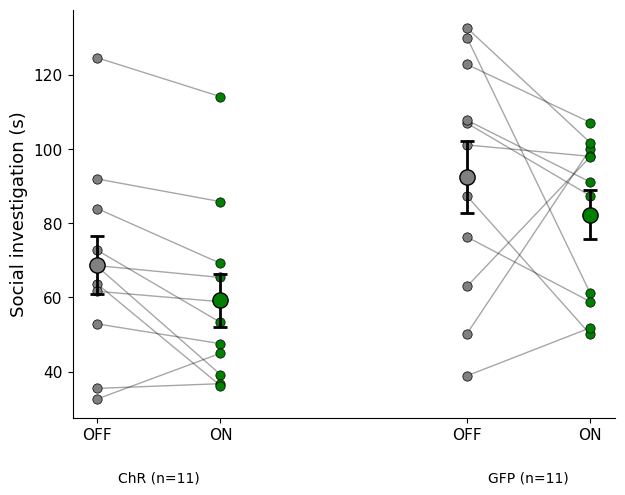

In [83]:
# ============================================================
# SOCIAL INVESTIGATION — SUBJECT ONLY
# OFF = Gray | ON = Green
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

positions = {
    ("ChR", "OFF"): 0,
    ("ChR", "ON"): 1,
    ("GFP", "OFF"): 3,
    ("GFP", "ON"): 4
}

# Same color convention as Cohort 1
laser_colors = {
    "OFF": "gray",
    "ON": "green"
}

# ============================================================
# INDIVIDUAL PAIRED MICE
# ============================================================

for group in ["ChR", "GFP"]:

    tmp = paired_df[paired_df["Group"] == group]

    x_off = positions[(group, "OFF")]
    x_on  = positions[(group, "ON")]

    for _, row in tmp.iterrows():

        # Pairing line
        ax.plot(
            [x_off, x_on],
            [row["OFF"], row["ON"]],
            color="black",
            alpha=0.35,
            linewidth=1,
            zorder=1
        )

        # OFF
        ax.scatter(
            x_off,
            row["OFF"],
            color=laser_colors["OFF"],
            edgecolor="black",
            linewidth=0.5,
            s=45,
            zorder=2
        )

        # ON
        ax.scatter(
            x_on,
            row["ON"],
            color=laser_colors["ON"],
            edgecolor="black",
            linewidth=0.5,
            s=45,
            zorder=2
        )

# ============================================================
# MEAN ± SEM
# ============================================================

for group in ["ChR", "GFP"]:

    tmp = paired_df[paired_df["Group"] == group]

    for condition in ["OFF", "ON"]:

        x = positions[(group, condition)]

        mean = tmp[condition].mean()
        sem = tmp[condition].sem()

        ax.errorbar(
            x,
            mean,
            yerr=sem,
            fmt="o",
            color="black",
            markerfacecolor=laser_colors[condition],
            markeredgecolor="black",
            markersize=11,
            linewidth=2,
            capsize=5,
            capthick=2,
            zorder=5
        )

# ============================================================
# AXES
# ============================================================

ax.set_xticks([0, 1, 3, 4])
ax.set_xticklabels(
    ["OFF", "ON", "OFF", "ON"],
    fontsize=11
)

ax.set_ylabel("Social investigation (s)", fontsize=13)

# ============================================================
# GROUP LABELS
# ============================================================

secax = ax.secondary_xaxis("bottom")

secax.set_xticks([0.5, 3.5])

secax.set_xticklabels(
    [
        f"ChR (n={sum(paired_df['Group'] == 'ChR')})",
        f"GFP (n={sum(paired_df['Group'] == 'GFP')})"
    ],
    fontsize=12,
    fontweight="bold"
)

secax.spines["bottom"].set_position(("outward", 35))
secax.spines["bottom"].set_visible(False)
secax.tick_params(axis="x", length=0)

# ============================================================
# CLEAN STYLE
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=11)

plt.subplots_adjust(bottom=0.20)
plt.show()

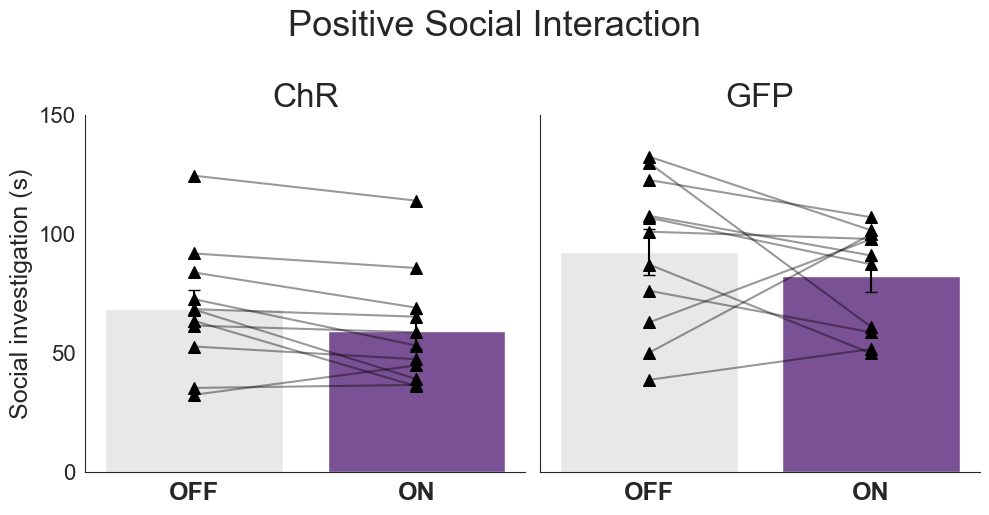

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

laser_order = ["OFF", "ON"]
group_order = ["ChR", "GFP"]

# Cohort 2 colors
palette_laser = {
    "OFF": "#E8E8E8",
    "ON":  "#7A5195"   # purple
}

# ============================================================
# CREATE TWO PANELS — ChR and GFP
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    sharey=True
)

# ============================================================
# PLOT EACH GROUP
# ============================================================

for ax, group in zip(axes, group_order):

    tmp = paired_df[
        paired_df["Group"] == group
    ].copy()

    x = np.arange(len(laser_order))

    # ========================================================
    # BARS: MEAN ± SEM
    # ========================================================

    means = [
        tmp["OFF"].mean(),
        tmp["ON"].mean()
    ]

    sems = [
        tmp["OFF"].sem(),
        tmp["ON"].sem()
    ]

    ax.bar(
        x,
        means,
        yerr=sems,
        color=[
            palette_laser["OFF"],
            palette_laser["ON"]
        ],
        capsize=4,
        width=0.8,
        zorder=1
    )

    # ========================================================
    # INDIVIDUAL PAIRED MICE
    # ========================================================

    for _, row in tmp.iterrows():

        ax.plot(
            x,
            [row["OFF"], row["ON"]],
            color="black",
            alpha=0.4,
            linewidth=1.5,
            zorder=3
        )

        # Cohort 2 males = triangles
        ax.scatter(
            x,
            [row["OFF"], row["ON"]],
            marker="^",
            color="black",
            s=70,
            zorder=4
        )

    # ========================================================
    # FORMATTING
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        laser_order,
        fontsize=18,
        fontweight="bold"
    )

    ax.set_title(
        group,
        fontsize=24
    )

    # Match Cohort 1 y-axis
    ax.set_ylim(0, 150)
    ax.set_yticks([0, 50, 100, 150])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="y",
        labelsize=16
    )

# ============================================================
# Y LABEL
# ============================================================

axes[0].set_ylabel(
    "Social investigation (s)",
    fontsize=18
)

axes[1].set_ylabel("")

# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "Positive Social Interaction",
    fontsize=26,
    y=1.02
)

plt.tight_layout()
plt.show()

In [89]:
for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        cols = [str(c).lower() for c in obj.columns]

        if any(
            word in col
            for col in cols
            for word in ["start", "stop", "time", "onset", "offset"]
        ):
            print("\n============================")
            print("DATAFRAME:", name)
            print("Shape:", obj.shape)
            print("Columns:", obj.columns.tolist())
            print(obj.head())


DATAFRAME: boris_df
Shape: (3937, 32)
Columns: ['Observation id', 'Observation date', 'Description', 'Observation type', 'Source', 'Time offset (s)', 'Coding duration', 'Media duration (s)', 'FPS (frame/s)', 'Subject', 'Observation duration by subject by observation', 'Behavior', 'Behavioral category', 'Behavior type', 'Start', 'Stop', 'Duration', 'Media file name', 'Image index start', 'Image index stop', 'Image file path start', 'Image file path stop', 'Comment start', 'Comment stop', 'SubjectID', 'Cage', 'Mouse', 'Group', 'Laser', 'Sex', 'File', ' Observation id']
                           Observation id         Observation date  \
0  10_1_RI1_c_on_20260711_105641.recfinal  2026-07-19 19:00:39.126   
1  10_1_RI1_c_on_20260711_105641.recfinal  2026-07-19 19:00:39.126   
2  10_1_RI1_c_on_20260711_105641.recfinal  2026-07-19 19:00:39.126   
3  10_1_RI1_c_on_20260711_105641.recfinal  2026-07-19 19:00:39.126   
4  10_1_RI1_c_on_20260711_105641.recfinal  2026-07-19 19:00:39.126   

   D

In [65]:
# ============================================================
# EFFECT SIZE FOR GROUP × LASER EFFECT
# Compare change scores: ChR vs GFP
# ============================================================

import numpy as np
from scipy import stats

# ------------------------------------------------------------
# CHANGE SCORES
# ------------------------------------------------------------

chr_change = paired_df.loc[
    paired_df["Group"] == "ChR",
    "Difference_ON_minus_OFF"
].dropna().values

gfp_change = paired_df.loc[
    paired_df["Group"] == "GFP",
    "Difference_ON_minus_OFF"
].dropna().values

n_chr = len(chr_change)
n_gfp = len(gfp_change)

mean_chr = np.mean(chr_change)
mean_gfp = np.mean(gfp_change)

sd_chr = np.std(chr_change, ddof=1)
sd_gfp = np.std(gfp_change, ddof=1)

# ------------------------------------------------------------
# DIFFERENCE IN CHANGE
#
# Negative = larger OFF -> ON decrease in ChR
# ------------------------------------------------------------

difference = mean_chr - mean_gfp

# Welch SE
se_diff = np.sqrt(
    (sd_chr**2 / n_chr) +
    (sd_gfp**2 / n_gfp)
)

# Welch degrees of freedom
df = (
    (sd_chr**2 / n_chr + sd_gfp**2 / n_gfp)**2
    /
    (
        ((sd_chr**2 / n_chr)**2 / (n_chr - 1)) +
        ((sd_gfp**2 / n_gfp)**2 / (n_gfp - 1))
    )
)

# 95% CI
tcrit = stats.t.ppf(0.975, df)

ci_low = difference - tcrit * se_diff
ci_high = difference + tcrit * se_diff

# ------------------------------------------------------------
# COHEN'S d
# Difference in change scores
# ------------------------------------------------------------

pooled_sd = np.sqrt(
    (
        (n_chr - 1) * sd_chr**2 +
        (n_gfp - 1) * sd_gfp**2
    )
    /
    (n_chr + n_gfp - 2)
)

cohens_d = difference / pooled_sd

# Hedges' correction
df_pooled = n_chr + n_gfp - 2

J = 1 - (3 / (4 * df_pooled - 1))

hedges_g = cohens_d * J

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("GROUP × LASER EFFECT")
print("----------------------------------")

print(f"ChR change: {mean_chr:.2f} ± {stats.sem(chr_change):.2f} s")
print(f"GFP change: {mean_gfp:.2f} ± {stats.sem(gfp_change):.2f} s")

print()
print(f"Difference in change (ChR - GFP): {difference:.2f} s")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}] s")

print()
print(f"Cohen's d: {cohens_d:.3f}")
print(f"Hedges' g: {hedges_g:.3f}")

GROUP × LASER EFFECT
----------------------------------
ChR change: -9.57 ± 3.75 s
GFP change: -10.18 ± 10.03 s

Difference in change (ChR - GFP): 0.61 s
95% CI: [-22.56, 23.79] s

Cohen's d: 0.024
Hedges' g: 0.024


In [66]:
# ============================================================
# 2 × 2 MIXED ANOVA
#
# Between-subject factor: Group (ChR vs GFP)
# Within-subject factor:  Laser (OFF vs ON)
# DV: Social investigation (s)
# ============================================================

import pingouin as pg
import pandas as pd

anova_df = investigation_df.copy()

# Make sure variables are categorical
anova_df["Group"] = anova_df["Group"].astype("category")
anova_df["Laser"] = anova_df["Laser"].astype("category")

# Mixed ANOVA
anova_results = pg.mixed_anova(
    data=anova_df,
    dv="Investigation_s",
    within="Laser",
    between="Group",
    subject="SubjectID",
    correction=False,
    effsize="np2"
)

display(anova_results)

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,Group,6020.211961,1,20,6020.211961,5.681347,0.027172,0.221225,NaN
1,Laser,1072.592876,1,20,1072.592876,3.404304,0.079887,0.145456,1.0
2,Interaction,1.034898,1,20,1.034898,0.003285,0.954865,0.000164,NaN


In [67]:
# ============================================================
# FELIX-ORTIZ / TYE STYLE POST-HOC TESTS
# Bonferroni-corrected comparisons
# ============================================================

from scipy.stats import ttest_rel, ttest_ind

# Separate groups
chr_df = paired_df[paired_df["Group"] == "ChR"].copy()
gfp_df = paired_df[paired_df["Group"] == "GFP"].copy()

# ------------------------------------------------------------
# 1. ChR: Laser OFF vs Laser ON
#    Paired because these are the same mice
# ------------------------------------------------------------

t_chr, p_chr = ttest_rel(
    chr_df["OFF"],
    chr_df["ON"]
)

# ------------------------------------------------------------
# 2. ChR vs GFP during Laser ON
#    Independent groups
# ------------------------------------------------------------

t_on, p_on = ttest_ind(
    chr_df["ON"],
    gfp_df["ON"],
    equal_var=True
)

# ------------------------------------------------------------
# Bonferroni correction
# Two post-hoc comparisons, matching the comparisons
# reported for social interaction in Felix-Ortiz/Tye
# ------------------------------------------------------------

p_chr_bonf = min(p_chr * 2, 1.0)
p_on_bonf  = min(p_on * 2, 1.0)

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("FELIX-ORTIZ / TYE STYLE POST-HOC TESTS")
print("=======================================")

print("\n1. ChR: OFF vs ON")
print(f"OFF = {chr_df['OFF'].mean():.2f} ± {chr_df['OFF'].sem():.2f} s")
print(f"ON  = {chr_df['ON'].mean():.2f} ± {chr_df['ON'].sem():.2f} s")
print(f"t = {t_chr:.3f}")
print(f"raw p = {p_chr:.4f}")
print(f"Bonferroni p = {p_chr_bonf:.4f}")

print("\n2. Laser ON: ChR vs GFP")
print(f"ChR = {chr_df['ON'].mean():.2f} ± {chr_df['ON'].sem():.2f} s")
print(f"GFP = {gfp_df['ON'].mean():.2f} ± {gfp_df['ON'].sem():.2f} s")
print(f"t = {t_on:.3f}")
print(f"raw p = {p_on:.4f}")
print(f"Bonferroni p = {p_on_bonf:.4f}")

FELIX-ORTIZ / TYE STYLE POST-HOC TESTS

1. ChR: OFF vs ON
OFF = 68.76 ± 7.78 s
ON  = 59.19 ± 7.18 s
t = 2.554
raw p = 0.0287
Bonferroni p = 0.0574

2. Laser ON: ChR vs GFP
ChR = 59.19 ± 7.18 s
GFP = 82.28 ± 6.66 s
t = -2.356
raw p = 0.0288
Bonferroni p = 0.0575


In [68]:
# ============================================================
# GFP LIGHT CONTROL
# OFF vs ON within GFP mice
# ============================================================

t_gfp, p_gfp = ttest_rel(
    gfp_df["OFF"],
    gfp_df["ON"]
)

print("GFP LIGHT CONTROL")
print("=================")

print(f"\nOFF = {gfp_df['OFF'].mean():.2f} ± {gfp_df['OFF'].sem():.2f} s")
print(f"ON  = {gfp_df['ON'].mean():.2f} ± {gfp_df['ON'].sem():.2f} s")

print(f"\nt = {t_gfp:.3f}")
print(f"p = {p_gfp:.4f}")

GFP LIGHT CONTROL

OFF = 92.46 ± 9.67 s
ON  = 82.28 ± 6.66 s

t = 1.015
p = 0.3338


In [69]:
# ============================================================
# BASELINE / LASER OFF GROUP COMPARISON
# ChR vs GFP during Laser OFF
# ============================================================

from scipy.stats import ttest_ind

chr_off = paired_df.loc[
    paired_df["Group"] == "ChR",
    "OFF"
].dropna()

gfp_off = paired_df.loc[
    paired_df["Group"] == "GFP",
    "OFF"
].dropna()

# Independent samples t-test
t_off, p_off = ttest_ind(
    chr_off,
    gfp_off,
    equal_var=True
)

print("LASER OFF: ChR vs GFP")
print("======================")

print(f"ChR: {chr_off.mean():.2f} ± {chr_off.sem():.2f} s")
print(f"GFP: {gfp_off.mean():.2f} ± {gfp_off.sem():.2f} s")

print(f"\nt = {t_off:.3f}")
print(f"df = {len(chr_off) + len(gfp_off) - 2}")
print(f"p = {p_off:.4f}")

LASER OFF: ChR vs GFP
ChR: 68.76 ± 7.78 s
GFP: 92.46 ± 9.67 s

t = -1.910
df = 20
p = 0.0705


In [70]:
# ============================================================
# PAIRED OFF vs ON TESTS WITHIN EACH VIRUS GROUP
# ============================================================

from scipy.stats import ttest_rel

for group in ["ChR", "GFP"]:

    tmp = paired_df[
        paired_df["Group"] == group
    ].dropna(subset=["OFF", "ON"])

    t, p = ttest_rel(
        tmp["OFF"],
        tmp["ON"]
    )

    print(f"\n{group}")
    print("--------------------------")
    print(f"n = {len(tmp)}")
    print(f"OFF: {tmp['OFF'].mean():.2f} ± {tmp['OFF'].sem():.2f} s")
    print(f"ON:  {tmp['ON'].mean():.2f} ± {tmp['ON'].sem():.2f} s")
    print(f"ON - OFF: {(tmp['ON'] - tmp['OFF']).mean():.2f} s")
    print(f"paired t = {t:.3f}")
    print(f"p = {p:.4f}")


ChR
--------------------------
n = 11
OFF: 68.76 ± 7.78 s
ON:  59.19 ± 7.18 s
ON - OFF: -9.57 s
paired t = 2.554
p = 0.0287

GFP
--------------------------
n = 11
OFF: 92.46 ± 9.67 s
ON:  82.28 ± 6.66 s
ON - OFF: -10.18 s
paired t = 1.015
p = 0.3338


In [71]:
# ============================================================
# TEMPORARILY EXCLUDE 14_2 FOR QC
# ============================================================

investigation_qc = investigation_df[
    investigation_df["SubjectID"] != "14_2"
].copy()

print("Subjects:", investigation_qc["SubjectID"].nunique())

print("\nSubjects per group:")
print(
    investigation_qc[
        ["SubjectID", "Group"]
    ]
    .drop_duplicates()["Group"]
    .value_counts()
)

Subjects: 21

Subjects per group:
Group
ChR    11
GFP    10
Name: count, dtype: int64


In [72]:
# ============================================================
# CREATE PAIRED OFF / ON DATA
# ============================================================

paired_qc = (
    investigation_qc
    .pivot_table(
        index=["SubjectID", "Cage", "Mouse", "Group", "Sex"],
        columns="Laser",
        values="Investigation_s"
    )
    .reset_index()
)

paired_qc.columns.name = None

paired_qc["Difference_ON_minus_OFF"] = (
    paired_qc["ON"] - paired_qc["OFF"]
)

display(paired_qc)

,SubjectID,Cage,Mouse,Group,Sex,OFF,ON,Difference_ON_minus_OFF
0,10_1,10,1,GFP,Male,50.253,100.035,49.782
1,10_2,10,2,GFP,Male,130.024,61.049,-68.975
2,10_3,10,3,GFP,Male,101.107,98.042,-3.065
3,10_4,10,4,GFP,Male,87.313,49.985,-37.328
4,11_2,11,2,ChR,Male,52.843,47.506,-5.337
5,11_3,11,3,ChR,Male,91.941,85.824,-6.117
6,11_4,11,4,ChR,Male,68.359,39.176,-29.183
7,12_2,12,2,GFP,Male,106.970,87.382,-19.588
8,12_3,12,3,GFP,Male,62.977,97.957,34.980
9,12_4,12,4,GFP,Male,132.643,101.697,-30.946


In [74]:
# ============================================================
# INSPECT ONE COHORT 2 RESPIRATION H5 FILE
# ============================================================

import h5py
import os

test_h5 = h5_files[0]

print("File:")
print(os.path.basename(test_h5))

print("\nH5 structure:")

with h5py.File(test_h5, "r") as f:

    def show_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"DATASET: {name} | "
                f"shape={obj.shape} | "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"GROUP:   {name}")

    f.visititems(show_structure)

File:
10_1_RI1_c_on_20260711_105641.h5

H5 structure:
GROUP:   analog
DATASET: analog/10_1_RI1_c_on_20260711_105641.analog_ECU_Ain1 | shape=(5355000,) | dtype=[('voltage', '<i2')]
DATASET: analog/10_1_RI1_c_on_20260711_105641.timestamps | shape=(5355000,) | dtype=[('time', '<u4')]
GROUP:   dio
DATASET: dio/10_1_RI1_c_on_20260711_105641.dio_ECU_Din1 | shape=(6571,) | dtype=[('time', '<u4'), ('state', 'u1')]
DATASET: dio/10_1_RI1_c_on_20260711_105641.dio_ECU_Dout1 | shape=(1,) | dtype=[('time', '<u4'), ('state', 'u1')]
GROUP:   time
DATASET: time/10_1_RI1_c_on_20260711_105641.timestamps | shape=(5355000,) | dtype=[('time', '<u4'), ('systime', '<i8')]


In [75]:
# ============================================================
# INSPECT ONE RAW RESPIRATION SIGNAL
# ============================================================

import h5py
import numpy as np
import os

test_h5 = h5_files[0]

with h5py.File(test_h5, "r") as f:

    # Find analog signal + timestamp datasets
    analog_group = f["analog"]

    signal_key = [
        k for k in analog_group.keys()
        if "analog_ECU_Ain1" in k
    ][0]

    timestamp_key = [
        k for k in analog_group.keys()
        if "timestamps" in k
    ][0]

    # Extract structured-array fields
    raw_signal = analog_group[signal_key]["voltage"][:]
    raw_time   = analog_group[timestamp_key]["time"][:]


print("File:")
print(os.path.basename(test_h5))

print("\nSamples:")
print(len(raw_signal))

print("\nSignal:")
print("dtype:", raw_signal.dtype)
print("min:", raw_signal.min())
print("max:", raw_signal.max())
print("mean:", raw_signal.mean())
print("std:", raw_signal.std())

print("\nTimestamp:")
print("first:", raw_time[0])
print("last:", raw_time[-1])

print("\nFirst 10 timestamp differences:")
print(np.diff(raw_time[:11]))

print("\nUnique early timestamp differences:")
print(np.unique(np.diff(raw_time[:10000]))[:20])

File:
10_1_RI1_c_on_20260711_105641.h5

Samples:
5355000

Signal:
dtype: int16
min: 408
max: 512
mean: 452.6486289449113
std: 8.599600961729186

Timestamp:
first: 4452797
last: 9807796

First 10 timestamp differences:
[1 1 1 1 1 1 1 1 1 1]

Unique early timestamp differences:
[1]


In [76]:
# ============================================================
# INSPECT H5 ATTRIBUTES / METADATA
# Look for sampling rate information
# ============================================================

import h5py
import os

test_h5 = h5_files[0]

with h5py.File(test_h5, "r") as f:

    print("FILE:", os.path.basename(test_h5))

    print("\nROOT ATTRIBUTES")
    print("----------------")
    for key, value in f.attrs.items():
        print(key, ":", value)

    print("\nALL GROUP / DATASET ATTRIBUTES")
    print("------------------------------")

    def show_attrs(name, obj):
        if len(obj.attrs) > 0:
            print(f"\n{name}")
            for key, value in obj.attrs.items():
                print("   ", key, ":", value)

    f.visititems(show_attrs)

FILE: 10_1_RI1_c_on_20260711_105641.h5

ROOT ATTRIBUTES
----------------

ALL GROUP / DATASET ATTRIBUTES
------------------------------

analog/10_1_RI1_c_on_20260711_105641.analog_ECU_Ain1
    accelerometer : -1
    autosettle : -1
    byte_order : little endian
    clockrate : 20000
    commit_tag : heads/Release_2.8.0-0-g3aff9620
    compile_date : Dec 30 2025
    compile_time : 12:23:57
    controller_firmware : 2.0
    controller_serialnum : 01703 00102
    description : One analog IO channel. Continuous sampling.
    direction : input
    display_order : 2
    fields : <voltage int16>
    first_timestamp : 4452797
    gyro : -1
    headstage_firmware : -1
    headstage_serialnum : -1
    id : ECU_Ain1
    magnetometer : -1
    original_file : 10_1_RI1_c_on_20260711_105641.rec
    qt_version : 6.7.2
    smartref : -1
    system_time_at_creation : 1783781826279
    time_offset : 0
    timestamp_at_creation : 555731
    trodes_version : 2.8.0

analog/10_1_RI1_c_on_20260711_105641.ti

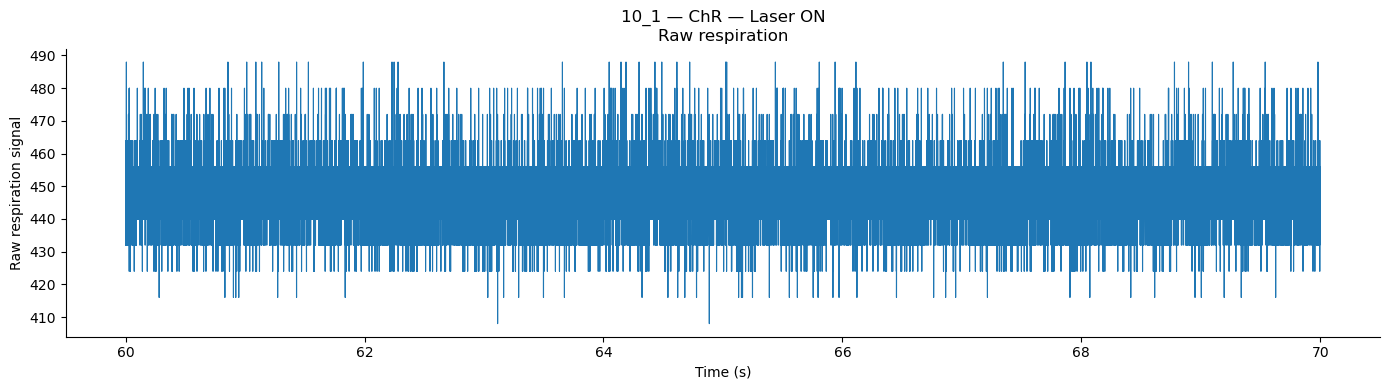

In [78]:
# ============================================================
# PLOT RAW RESPIRATION — 10 SECOND SEGMENT
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import h5py

fs = 20000  # Hz, from H5 clockrate attribute

# Let's inspect 60–70 seconds
start_sec = 60
end_sec   = 70

start_idx = int(start_sec * fs)
end_idx   = int(end_sec * fs)

# Time axis in seconds
t = np.arange(start_idx, end_idx) / fs

# Extract segment
resp_segment = raw_signal[start_idx:end_idx]

# Plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(
    t,
    resp_segment,
    linewidth=0.8
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Raw respiration signal")
ax.set_title(
    "10_1 — ChR — Laser ON\nRaw respiration"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [79]:
# Mice with unusable respiration recordings
RESP_EXCLUDE_MICE = {
    "9_1",
    "9_2",
    "9_4",
    "10_1",
    "10_4",
    "11_2",
    "11_4",
    "13_4",
    "14_4",
}
